In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
df=pd.read_csv("European_Bank.csv")

### Load DataSet

In [3]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [5]:
df["IsActiveMember"].unique()

array([1, 0])

In [6]:
df["IsActiveMember"].value_counts()

,count
IsActiveMember,
1,5151
0,4849


 The dataset shows a nearly balanced distribution between active (51.5%) and inactive(48.5%) customers.This balanced representation ensures that engagement-based churn analysis is not biased and highlights the importance of activity status as a key factor in understanding customer churn.

In [7]:
df["NumOfProducts"].unique()

array([1, 3, 2, 4])

In [8]:
df["NumOfProducts"].dtype

dtype('int64')

In [9]:
df["NumOfProducts"].value_counts()

,count
NumOfProducts,
1,5084
2,4590
3,266
4,60


The majority of customers hold either one (50.8%) or two (45.9%) products, accounting for approximately 97% of the dataset.Only a small proportion of customers have three or more products, indicating that multi-product engagement is relatively low among customers.

In [10]:
df[df["IsActiveMember"].isin([1,0])]

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,2025,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,2025,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,2025,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [11]:
binary_cols=["IsActiveMember","HasCrCard","Exited"]

In [12]:
for col in binary_cols:
    print(col)
    print("Unique:",df[col].unique())
    print("Missing:",df[col].isnull().sum())
    print("Invalid Values:",df[~df[col].isin([1,0])].shape[0])
    print("----")

IsActiveMember
Unique: [1 0]
Missing: 0
Invalid Values: 0
----
HasCrCard
Unique: [1 0]
Missing: 0
Invalid Values: 0
----
Exited
Unique: [1 0]
Missing: 0
Invalid Values: 0
----


In [13]:
df[['HasCrCard','Exited']].dtypes

,0
HasCrCard,int64
Exited,int64


In [14]:
df["Exited"].unique()

array([1, 0])

In [15]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


In [16]:
df['Exited'].value_counts(normalize=True)*100

,proportion
Exited,
0,79.63
1,20.37


The target variable indicates that 79.63% of customers are retained, while 20.37% have churned. Although the majority of customers remain, the churn rate is significant, with approximately one in five customers exiting. This highlights the importnace of identifying key drivers of churn to improve customer retention and reduce potential revenue loss.

In [17]:
df.groupby('Exited')['IsActiveMember'].mean()
df.groupby('Exited')['NumOfProducts'].mean()
df.groupby('Exited')['Balance'].mean()

,Balance
Exited,
0,72745.296779
1,91108.539337


Analysis shows that churned customers have a significantly higher average balance (91,108) compared to retained customers (72,745).This suggests that high-value customers are more prone to churn, leading to greater potential revenue loss. This highlights the need for targeted retention strategies focused on financially valuable customers.

In [18]:
df.columns=df.columns.str.strip()

In [19]:
df=df.drop(columns=['Surname','CustomerId','Year'],axis=1,errors='ignore')

In [20]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [21]:
df.select_dtypes(include='object').columns

Index(['Geography', 'Gender'], dtype='object')

In [22]:
df.groupby('Geography')['Exited'].mean()

,Exited
Geography,
France,0.161548
Germany,0.324432
Spain,0.166734


Geographic analysis reveals substantial variation in churn behavior. Germany shows a significantly higher churn rate (32.44%) compared to France (16.15%) and Spain (16.67%), nearly double that of the other regions.This suggests potential regional factors such as customer dissatisfaction, competitive pressure, or service-related issues contributing to higer attrition in Germany.

In [23]:
df.groupby('Gender')['Exited'].mean()

,Exited
Gender,
Female,0.250715
Male,0.164559


Gender-based analysis reveals that female customers have a significantly higher churn rate (25.07%) compared to male customers (16,.46%),making them approximately 1.5 times more likely to churn. This suggests potential differences in customer experience,expectations or engagement levels, highlighting the need for targeted retention strategies for female customers.

In [24]:
df["AgeGroup"]=pd.cut(df['Age'],bins=[18,30,45,60,100],labels=["<30","30-45","46-60","60+"])

In [25]:
df['AgeGroup'].value_counts()

,count
AgeGroup,
30-45,5921
<30,1946
46-60,1647
60+,464


The age distribution shows that the majority of customers fall within the 30-45 age group (59.2%), followed by customers below 30 (19.5%) and those aged 46-60 (16.5%). only a small proportion (4.6%) of the customers are above 60, indicating that the dataset is heavily concentrated around middle-aged individuals.

In [26]:
df["Balance_Segment"]=pd.cut(df["Balance"],bins=[-1,0,100000,df["Balance"].max()],labels=["Zero-Balance","Low-Balance","High-Balance"])

In [27]:
df['Balance_Segment'].value_counts()

,count
Balance_Segment,
High-Balance,4799
Zero-Balance,3617
Low-Balance,1584


The balance segmentation reveals that nearly half of the customers (48.0%) belong to the high-balance category, while a significant proportion (36.2%) maintain zero balance. Only 15.8% of thwe customers fall into the low-balance segment. This polarized distribution indicates distinct customer groups, where high-balance customers represent high-value accounts, while zero-balance customers may indicate low engagement or inactive accounts.

In [28]:
df['Credit_Risk']=pd.cut(df['CreditScore'],bins=[300,600,700,850],labels=['Low','Medium','High'])

In [29]:
df['Credit_Risk'].value_counts()

,count
Credit_Risk,
Medium,3818
High,3116
Low,3066


The distribution of customers across credit risk segments is relatively even, with a slight concentration in the medium-risk category (38.2%), followed by high-risk (31.2%) and low-risk (30.7%) segments. This balanced representation ensures that credit risk can be effectively analyzed as a factor influencing customer churn without bias toward any particular segment.

In [30]:
df['Product_Segment']=pd.cut(df['NumOfProducts'],bins=[0,1,2,4],labels=['Single Product','Two Products','Multiple Products'])

In [31]:
df['Product_Segment'].value_counts()

,count
Product_Segment,
Single Product,5084
Two Products,4590
Multiple Products,326


The distribution of product usage reveals that the majority of customers hold either a single product (50.8%) or two products (45.9%), together accounting for approximately 97% of the customer base. Only a small fraction (3.3%) use multiple products, indicating low multi-product engagement. This suggests an opportunity for cross-selling strategies, as customers with higher product usage are typically more engaged and potentially less likely to churn.

In [32]:
df['Salary_Segment']=pd.qcut(df['EstimatedSalary'],q=4,labels=['Low','Lower-Mid','Upper-Mid','High'])

In [33]:
df['Salary_Segment'].value_counts()

,count
Salary_Segment,
Low,2500
Lower-Mid,2500
Upper-Mid,2500
High,2500


The salary segmentation shows a perfectly balanced distribution, with each category (Low, Lower-Mid, Upper-Mid, High) comprising 25% of the dataset. This uniform distribution ensures that comparisons across income groups can be made without bias, making salary an effective variable for analyzing differences in churn behavior.

In [34]:
df['Tenure_Segment']=pd.cut(df["Tenure"],bins=[0,3,7,10],labels=["New","Mid-term","Long-term"])

In [35]:
df['Tenure_Segment'].value_counts()

,count
Tenure_Segment,
Mid-term,3996
New,3092
Long-term,2499


The tenure segmentation reveals that 40.0% of customers fall into the mid-term category, while 30.9% are new customers and 25.0% are long-term customers. This relatively balanced distribution suggests that the dataset captures customers across different stages of their relationship with the bank, enabling meaningful analysis of churn behavior across the customer lifecycle.

In [36]:
df.groupby('AgeGroup',observed=True)['Exited'].mean()*100

,Exited
AgeGroup,
<30,7.502569
30-45,15.740584
46-60,51.123254
60+,24.784483


Age-based analysis reveals a strong relationship between age churn. Customers in the 46-60 age group exhibit an exceptionally high churn rate of 51.12%, significantly highr than all other segments. In contrast, younger customers (<30) show minimal churn (7.50%). This trend suggests that middle-aged customers are the most vulnerable to churn, possibly due to changing financial needs or competitive alternatives.

In [37]:
df.groupby('Balance_Segment',observed=True)['Exited'].mean()*100

,Exited
Balance_Segment,
Zero-Balance,13.823611
Low-Balance,20.580808
High-Balance,25.234424


Analysis of churn across balance segments reveals a clear upward trend, where high-balance customers exhibit the highest churn rate (25.23%),followed by low-balance (20.58%) and zero-balance customers (13.82%). This indicates that high-value customers are more prone to churn, posing a significant risk to revenue. Retaining these customers should be a key priority for the business.

In [38]:
df.groupby('Credit_Risk',observed=True)['Exited'].mean()*100


,Exited
Credit_Risk,
Low,21.689498
Medium,19.722368
High,19.865212


Analysis of churn across credit risk segments shows minimal variation, with churn rates ranging between 19% and 22%. Interestingly, low-risk customers exhibit slightly higher churn (21.68%) compared to medium and high-risk segments. This suggests that credit risk is not a strong predictor of churn, and other factors such as balance, age, and engagement play a more significant role.

In [39]:
df.groupby('Product_Segment',observed=True)['Exited'].mean()*100

,Exited
Product_Segment,
Single Product,27.714398
Two Products,7.581699
Multiple Products,85.889571


Product-based analysis reveals that customers with two products have the lowest churn rate (7.58%), indicating strong engagement and retention. Single-product customers exhibit higher churn (27.71%), suggesting lower engagement. Interestingly, customers with multiple products show an extremely high churn rate (85.88%); however, this segment represents a very small portion of the dataset, which may lead to skewed results. Overall, moderate product usage appears to be associated with higher customer stability.

In [40]:
df.groupby('Salary_Segment',observed=True)['Exited'].mean()*100

,Exited
Salary_Segment,
Low,20.00
Lower-Mid,19.80
Upper-Mid,20.12
High,21.56


The analysis of customer churn across different salary groups shows that the High Salary Segment experiences the highest churn at 21.56%, while the Lower Mid Segment has the lowest at 19.80%. The Low and Upper Mid salary groups have churn rates close to 20%,indicating relatively minor differences across categories. Overall, the variation in churn by salary is small, suggesting that salary alone is not a strong driver of customer exits. To better understand churn patterns,it may be useful to consider salary in combination with other factors such as account balance, product usage, and credit risk.

In [41]:
df.groupby('Tenure_Segment',observed=True)['Exited'].mean()*100

,Exited
Tenure_Segment,
New,20.892626
Mid-term,19.644645
Long-term,20.448179


The churn analysis across customer tenure shows that New Customers have highest exit rate 20.89%,followed by Long Term customers at 20.44%, while Mid Term customers exhibit the lowest churn at 19.64%. The differences in churn across tenure categories are relatively small, indicating that tenure alone does not strongly influence customer exits. However, new customers show a slightly higher tendency to leave, suggesting that engagement strategies targeting early-stage customers could help reduce churn. Combining tenure with other factors such as salary, product usage, and credit risk may provide deeper insights into churn behavior.

In [42]:
pivot_age_geo=pd.pivot_table(df,values="Exited",observed=True,index="Geography",columns="AgeGroup",aggfunc="mean")*100
pivot_age_geo

AgeGroup,<30,30-45,46-60,60+
Geography,,,,
France,4.868549,12.349800,45.794393,19.913420
Germany,12.527964,26.092991,67.330677,38.938053
Spain,8.474576,12.533693,40.656566,20.833333


The most striking trend across all three countries is the massive spike in churn within the 46-60 age group. In Germany, this reaches a staggering 67.33%, while France and Spain also see their highest exit rates in this bracket (approx.45.8% and 40.7%, respectively). This suggests that middle-aged customers are significantly more likely to leave the bank, regardless of their location.

Germany consistently exhibits higher churn rates compared to France and Spain across every single age category. Even in the younger demographic (<30), Germany's churn rate is 12.5%, which is more than double France's 4.87%. This indicates a potential systemic issue or higher market competition specifically affecting the German customer base.

The under 30 age group appears to be the most loyal (or least likely exit), with France showing the lowest churn rate at 4.87%. There is also a noticeable "cool down" in churn for customers aged 60+ compared to 46-60 bracket, though the rates still remain higher than those of the younger populations (under 45).

In [43]:
pivot_balance_tenure=pd.pivot_table(df,values="Exited",observed=True,index="Balance",columns="Tenure",aggfunc="mean")*100
pivot_balance_tenure=pivot_balance_tenure.fillna(0)
pivot_balance_tenure

Tenure,0,1,2,3,4,5,6,7,8,9,10
Balance,,,,,,,,,,,
0.00,14.59854,16.905444,16.753927,13.352273,14.634146,12.834225,13.896458,12.176166,9.641873,12.5,16.853933
3768.69,100.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
12459.19,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.0,0.000000
14262.80,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
16893.59,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
216109.88,0.00000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.0,0.000000
221532.80,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
222267.63,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.0,0.000000


The pivot table analyzing the relationship between Balance, Tenure, and churn rate reveals a polarized and somewhat fragmented data landscape. A critical observation is the behavior of customers with 0.00 balance; they show a relatively consistent churn rate ranging from roughly 9.6% to 16.9% across all tenure levels. This suggests that for "empty" accounts, the length of time they've been with the bank doesn't significantly protect against churn, though there is a slight dip in exits around year 8.

The rest of the table reveals a high concentration of extreme values (0% or 100%) for specific balance amounts. This pattern typically indicates that at higher or  more specific balance increments, the sample size per "cell" becomes very small- often representing only a single customer.  For instance, customers with very high balances (e.g.$238k or $250k) show a 100% churn rate at specific tenures, while others show 0%. While these 100% marks look alarming, they are likely outliers rather than broad trends. The most actionable takeaway is the "Zero Balance" row, which serves as a more reliable baseline, indicating that low-engagement (zero-balance) customers are a constant churn risk regardless of how long they have held their accounts.

In [44]:
df["Exited"]=df["Exited"].map({0:0,1:1,"Yes":1,"No":0})

In [45]:
df["Gender"]=df["Gender"].fillna("Unknown")

In [46]:
df["Age"]=pd.to_numeric(df["Age"],errors="coerce")

In [47]:
df["Balance"]=pd.to_numeric(df["Balance"],errors="coerce")

In [48]:
df=df.dropna(subset=["Age","Geography"])

###  Overall Churn Rate

In [49]:
overall_churn_rate=df["Exited"].mean()*100

In [50]:
print(f"Overall Churn Rate:{overall_churn_rate:.2f}%")

Overall Churn Rate:20.37%


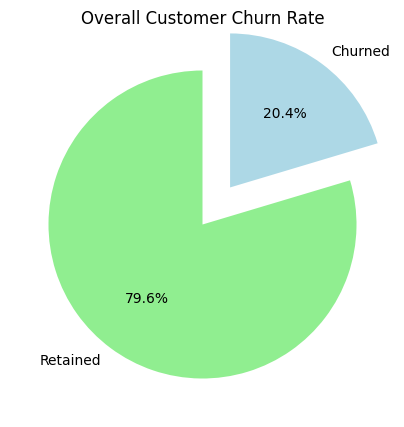

In [51]:
churn_count=df["Exited"].value_counts()
labels=["Retained","Churned"]
plt.figure(figsize=(5,5))
plt.pie(churn_count,labels=labels,autopct="%1.1f%%",colors=["lightgreen","lightblue"],startangle=90,explode=[0,0.3])
plt.title("Overall Customer Churn Rate")
plt.show()

The pie chart confirms a 20.4% churn rate, establishing a baseline where approximately one-fifth of the total customer base has exited the bank. While the majority of customers (79.6%) remain retained, this 1:5 ratio of loss is high enough to suggest that churn is a systemic issue rather than a series of isolated incidents.

In [52]:
age_dist=df.groupby("AgeGroup",observed=True).agg(Total_Customers=("Exited","count"),Churned_Customers=("Exited","sum"))
age_dist["Churn_Rate (%)"]=(age_dist["Churned_Customers"]/age_dist["Total_Customers"])*100
total_churn=df["Exited"].sum()
age_dist["Churn_Contribution (%)"]=(age_dist["Churned_Customers"]/total_churn)*100
age_dist

,Total_Customers,Churned_Customers,Churn_Rate (%),Churn_Contribution (%)
AgeGroup,,,,
<30,1946,146,7.502569,7.167403
30-45,5921,932,15.740584,45.753559
46-60,1647,842,51.123254,41.335297
60+,464,115,24.784483,5.645557


The Danger Zone: While (46-60) age group isn't the largest in total volume, it has a staggering 51.1% churn rate. Over half of the customers in this age bracket are leaving the bank.

The Bulk of the Loss: The (30-45) age group represents the largest customer base (5,921 people). Because of its size, even a 15.7% churn rate accounts for the highest total contribution to churn (45.75%).

Youth Retention: The under-30 demographic is the most loyal (or least likely to leave), with only a 7.5% churn rate.

The Overall Problem: Combined, customers aged 30 to 60 accounts for 87% of all churned customers.


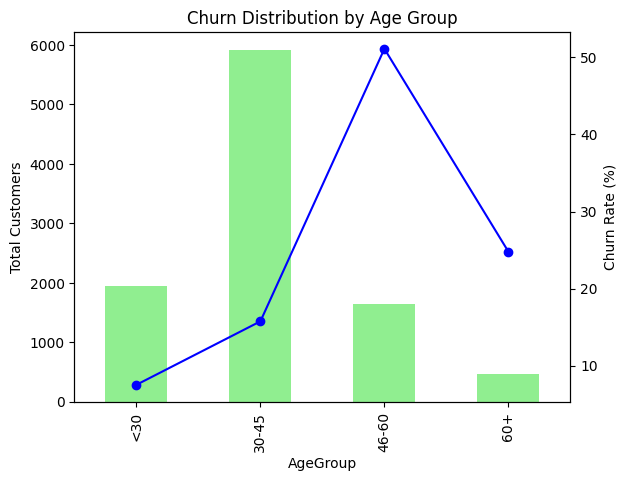

In [53]:
fig,ax1=plt.subplots()
age_dist["Total_Customers"].plot(kind="bar",color="lightgreen",ax=ax1)
ax1.set_ylabel("Total Customers")

ax2=ax1.twinx()
age_dist["Churn_Rate (%)"].plot(color="blue",marker="o",ax=ax2)
ax2.set_ylabel("Churn Rate (%)")
plt.title("Churn Distribution by Age Group")
plt.show()

As the green bars  (Total Customers) decrease in the 46-60 and 60+ ranges, the blue line (Churn Rate) spikes significantly.
This suggests that as customers age within the bank, they are becoming increasingly dissaisfied or are being retirement or wealth management products.

In [54]:
balance_dist=df.groupby("Balance_Segment",observed=True).agg(Total=("Exited","count"),Churned=("Exited","sum"))

balance_dist["Churn_Rate (%)"]=(balance_dist["Churned"]/balance_dist["Total"])*100
balance_dist["Contribution (%)"]=(balance_dist["Churned"]/df["Exited"].sum())*100

balance_dist

,Total,Churned,Churn_Rate (%),Contribution (%)
Balance_Segment,,,,
Zero-Balance,3617,500,13.823611,24.545901
Low-Balance,1584,326,20.580808,16.003927
High-Balance,4799,1211,25.234424,59.450172


The Heavy Hitters are Leaving: The "High-balance" group isn't just churning at the highest rate (1 in 4); they account for nearly 60% of the total churned population. This is a massive hit to the bank's liquidity and assets under management.

Zero-Balance "Stickiness": Interestingly, customers with no money in their accounts are the least likely to churn (13.8%). This could be due to "dormant" accounts- people who have forgotten about the account or simply don't care enough to close it because there is no risk to them.

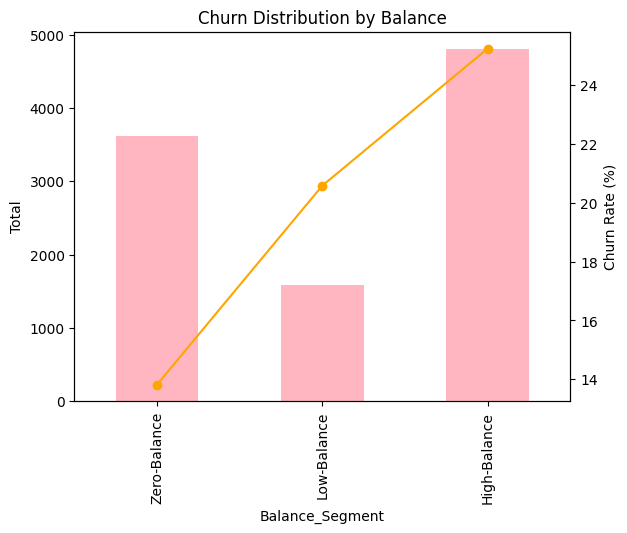

In [55]:
fig,ax1=plt.subplots()
balance_dist["Total"].plot(kind="bar",color="lightpink",ax=ax1)
ax1.set_ylabel("Total")

ax2=ax1.twinx()
balance_dist["Churn_Rate (%)"].plot(color="orange",marker="o",ax=ax2)
ax2.set_ylabel("Churn Rate (%)")
plt.title("Churn Distribution by Balance")
plt.show()

This dual-axis chart clearly shows the orange line (Churn Rate) climbing steadily as we move from left to right. This suggests that the more skin a customer has in the game, the more likely they are to exit.

In [56]:
credit_dist=df.groupby("Credit_Risk").agg(Total_Customers=("Exited","count"),Churned_Customers=("Exited","sum"))
credit_dist["Churn_Rate (%)"]=(credit_dist["Churned_Customers"]/credit_dist["Total_Customers"])*100
credit_dist["Churn_Contribution (%)"]=(credit_dist["Churned_Customers"]/df["Exited"].sum())*100
credit_dist

/tmp/ipykernel_5059/3926294564.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Total_Customers,Churned_Customers,Churn_Rate (%),Churn_Contribution (%)
Credit_Risk,,,,
Low,3066,665,21.689498,32.646048
Medium,3818,753,19.722368,36.966127
High,3116,619,19.865212,30.387825


The "Low Risk" Paradox: Counter-intuitively, your "Low Risk" customers (those with presumably higher credit scores) have the highest churn rate (21.69%). Usually, banks expect low-risk customers to be more stable. This suggests that these 'prime" customers might be more financially savvy and are actively shopping around for better offers or lower interest rates at other banks.

Uniform Contribution: Churn contribution is split almost equally into thirds (roughly 30-37% each). This means Credit Risk is a poor diferentiator on its own for predicting who will leave- it's happening across the board.

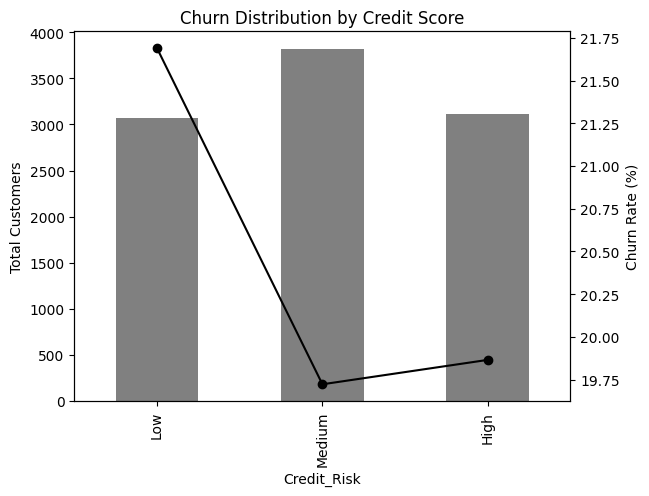

In [57]:
fig,ax1=plt.subplots()
credit_dist["Total_Customers"].plot(kind="bar",color="grey",ax=ax1)
ax1.set_ylabel("Total Customers")

ax2=ax1.twinx()
credit_dist["Churn_Rate (%)"].plot(color="black",marker="o",ax=ax2)
ax2.set_ylabel("Churn Rate (%)")
plt.title("Churn Distribution by Credit Score")
plt.show()

This dual-axis plot shows the churn rate line (black) dipping for Medium risk and staying flat for High risk. The total volume of customers (bars) is highest in the "Medium" risk category.

In [58]:
product_dist=df.groupby("NumOfProducts").agg(Total_Customers=("Exited","count"),Churned_Customers=("Exited","sum"))
product_dist["Churn_Rate (%)"]=(product_dist["Churned_Customers"]/product_dist["Total_Customers"])*100
product_dist["Churn_Contribution (%)"]=(product_dist["Churned_Customers"]/df["Exited"].sum())*100
product_dist

,Total_Customers,Churned_Customers,Churn_Rate (%),Churn_Contribution (%)
NumOfProducts,,,,
1,5084,1409,27.714398,69.170349
2,4590,348,7.581699,17.083947
3,266,220,82.706767,10.800196
4,60,60,100.000000,2.945508


The Power of Two: Customers with exactly 2 products are the most loyal group by a massive margin. Their churn rate (7.58%) is nearly 4x lower than those with only 1 product. This is likely because 2 products suggest a deeper "hook" into the bank (e.g., a checking account + credit card) without being overwhelmed.

The Single-Product Trap: Those with only 1 product account for nearly 70% of all churn. This group has low switching costs; if they aren't satisfied, they leave easily because they aren't integrated into the ecosystem.

The Multi-Product Collapse: This is the most unusual finding. Once a customer hits 3 or 4 products, the churn rate sky-rockets to 82% and 100%, respectively. While these groups are small in total volume, their behavior is catastrophic.

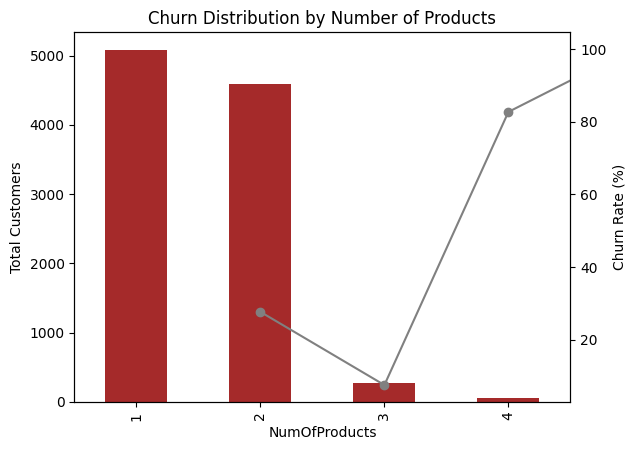

In [59]:
fig,ax1=plt.subplots()
product_dist["Total_Customers"].plot(kind="bar",color="brown",ax=ax1)
ax1.set_ylabel("Total Customers")

ax2=ax1.twinx()
product_dist["Churn_Rate (%)"].plot(color="grey",marker="o",ax=ax2)
ax2.set_ylabel("Churn Rate (%)")
plt.title("Churn Distribution by Number of Products")
plt.show()

The bars show that the vast majority of the customers have 1 or 2 products.
The line shows a massive spike at the 3 and 4 marks. Usually, in banking, "more products=more loyalty". Here, the opposite is true. This often indicates product pushing-customers might have been sold products they didn't need or want, leading to frustration and exit.

In [60]:
salary_dist=df.groupby("Salary_Segment",observed=True).agg(Total_Customers=("Exited","count"),Churned_Customers=("Exited","sum"))
salary_dist["Churn_Rate (%)"]=(salary_dist["Churned_Customers"]/salary_dist["Total_Customers"])*100
salary_dist["Churn_Contribution"]=(salary_dist["Churned_Customers"]/df["Exited"].sum())*100
salary_dist

,Total_Customers,Churned_Customers,Churn_Rate (%),Churn_Contribution
Salary_Segment,,,,
Low,2500,500,20.00,24.545901
Lower-Mid,2500,495,19.80,24.300442
Upper-Mid,2500,503,20.12,24.693176
High,2500,539,21.56,26.460481


The "Flat" Variable: the difference between the highest churn rate (High Salary) and the lowest (Lower-Mid) is only 1.76%. In data analytics, this is usually suggested that salary is a "noisy" or weak predictor. Whether a customer earns a lot or a little, their likelihood of leaving the bank remains roughly 1 in 5.

Uniform Impact: Each segment contributes almost exactly 25% to the total churn pool. This tells us that financial "means" (how much hey earn) isn't the driver- financial "behavior" (how much they keep in the bank and how many products they use) is.

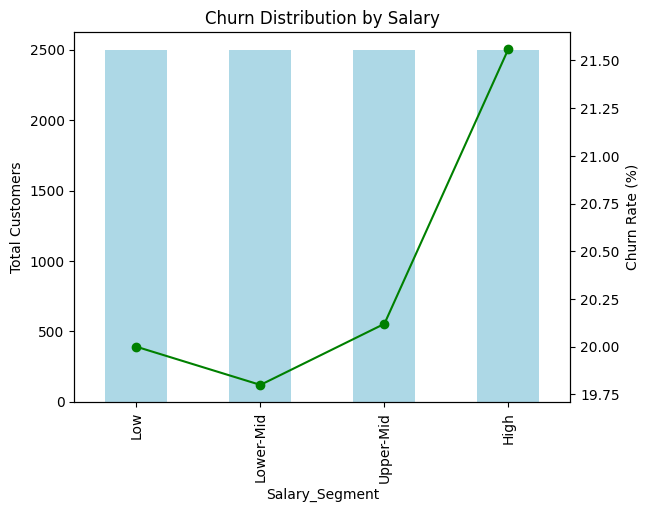

In [61]:
fig,ax1=plt.subplots()
salary_dist["Total_Customers"].plot(kind="bar",color="lightblue",ax=ax1)
ax1.set_ylabel("Total Customers")

ax2=ax1.twinx()
salary_dist["Churn_Rate (%)"].plot(color="green",marker="o",ax=ax2)
ax2.set_ylabel("Churn Rate (%)")
plt.title("Churn Distribution by Salary")
plt.show()

The chart shows four identical bars, and while the black line (Churn Rate) looks like it's spiking at the "High" end, look at Y-axis scale on the right. It only ranges from 19.75% to 21.50%. This is a micro-fluctuation, not a major trend.

In [62]:
tenure_dist=df.groupby("Tenure").agg(Total_Customers=("Exited","count"),Churned_Customers=("Exited","sum"))
tenure_dist["Churn_Rate (%)"]=(tenure_dist["Churned_Customers"]/tenure_dist["Total_Customers"])*100
tenure_dist["Churn_Contribution (%)"]=(tenure_dist["Churned_Customers"]/df["Exited"].sum())*100
tenure_dist

,Total_Customers,Churned_Customers,Churn_Rate (%),Churn_Contribution (%)
Tenure,,,,
0,413,95,23.002421,4.663721
1,1035,232,22.415459,11.389298
2,1048,201,19.179389,9.867452
3,1009,213,21.110010,10.456554
4,989,203,20.525784,9.965636
5,1012,209,20.652174,10.260187
6,967,196,20.268873,9.621993
7,1028,177,17.217899,8.689249
8,1025,197,19.219512,9.671085


The "Newbie" Peak: Customers in their first year (Tenure 0 and 1) have the highest churn rates at 3% and 22.4%. This is a classic "onboarding" issue- if te bank dose prove its value immediately, the customer leaves.

The "7-Year Itch" (Lowest Churn): Year 7 is the "sweet spot" where churn dips to its lowest point(17.2%). This suggests that if a customer survives past the 5-year mark, they reach a period of maximum stability.

The Late-Stage Bounce: Surprisingly, churn creeps back up after Year 7. By Year 9 and 10, the churn rate is back over 29%. This is unusual- normally, 10-year veterans are "locked in". This suggeststhat long-term customers might feel neglected or that "new customer" promotions at other banks are successfully luring them away.

Uniform Contribution: Because the number of customers is spread relatively evenly across all tenure years (around 1000 per year, except for the extremes), no single year "owns" the churn problem. It is a persistent issue throughout the customer lifecycle.

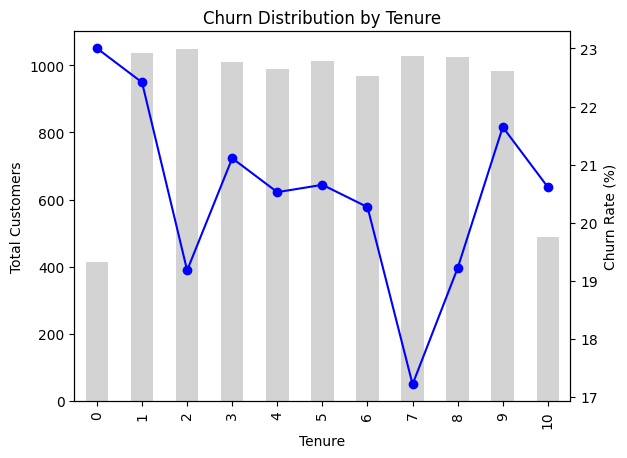

In [63]:
fig,ax1=plt.subplots()
tenure_dist["Total_Customers"].plot(kind="bar",color="lightgrey",ax=ax1)
ax1.set_ylabel("Total Customers")

ax2=ax1.twinx()
tenure_dist["Churn_Rate (%)"].plot(color="blue",marker="o",ax=ax2)
ax2.set_ylabel("Churn Rate (%)")
plt.title("Churn Distribution by Tenure")
plt.show()

The chart shows a very "jagged" blue line. In statistics, this often indicates that while there are small fluctuations, Tenure is a weak predictor of churn compared to Age or Number of Products. The bank is losing people almost regardless of how long they've been there.

In [64]:
churned=df[df["Exited"]==1]
retained=df[df["Exited"]==0]

In [65]:
comparison=pd.DataFrame({"Churned":churned[["Age","Balance","NumOfProducts","CreditScore","EstimatedSalary","Tenure"]].mean(),"Retained":retained[["Age","Balance","NumOfProducts","CreditScore","EstimatedSalary","Tenure"]].mean()})

comparison

,Churned,Retained
Age,44.837997,37.408389
Balance,91108.539337,72745.296779
NumOfProducts,1.475209,1.544267
CreditScore,645.351497,651.853196
EstimatedSalary,101465.677531,99738.391772
Tenure,4.932744,5.033279


The "Age Gap': This is the most statisically significant finding. Churned customers are, on average, over 7 years older than those who stay. This reinforces the previous finding that the 46-60 age bracket is the primary churn driver.

The "Balnce Gap": Churned customers leave behind significantly higher balances (about 25% higher) than the average retained customer. This confirms that churn is costing the bank its most liquid and profitable clients.

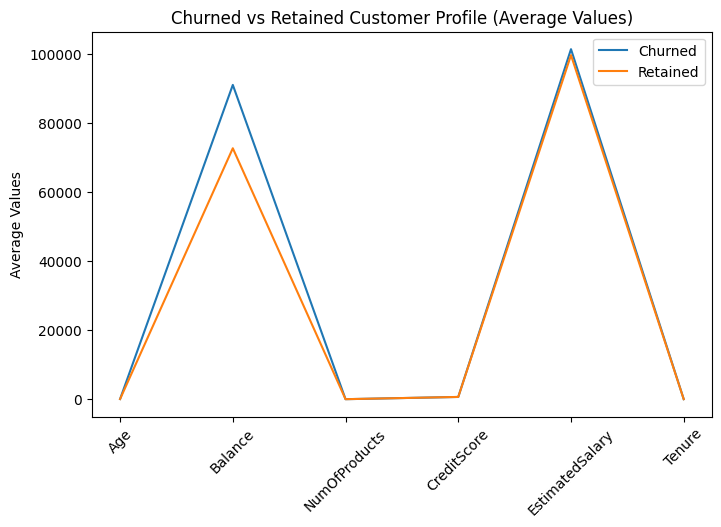

In [66]:
comparison.plot(kind="line",figsize=(8,5))

plt.title("Churned vs Retained Customer Profile (Average Values)")
plt.ylabel("Average Values")
plt.xticks(rotation=45)
plt.show()

The blue line  (Churnd) spikes significantly higher than the red line (Retained) at the Balance and Age markers.
The lines converge and become nearly identical for NumOfProducts, Creditscore, EstimatedSalary and Tenure.

Despite what one might assume, churned customers haven't been with the bank for a shorter time, nor do they earn significantly more or less than retained customers. These lines on the graph overlap are non-discriminatory factors.

In [67]:
gender_churn=df.groupby("Gender")["Exited"].mean()*100
gender_churn

,Exited
Gender,
Female,25.071539
Male,16.455928


 Women are roughly 1.5 times more likely to leave the bank than men. While the overall churn rate for the bank is ~20%, women are well above that baseline at 25%, whereas men are below it.

In [68]:
gender_counts=churned["Gender"].value_counts()

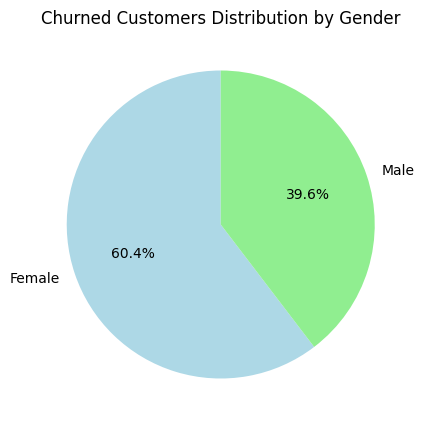

In [69]:
plt.figure(figsize=(5,5))
plt.pie(gender_churn,labels=gender_churn.index,autopct="%1.1f%%",colors=["lightblue","lightgreen"],startangle=90)
plt.title("Churned Customers Distribution by Gender")
plt.show()

The pie chart clearly shows that 6 out of 10 customers who leave are female. This is a massive imbalance that suggests the bank's current products, communication style, or services may be failing to meet the specific needs or expectations of its female clientele.

In [70]:
gender_dist=pd.crosstab(df["Gender"],df["Exited"],normalize="index")*100
gender_dist.columns=["Retained (%)","Churned (%)"]
gender_dist

,Retained (%),Churned (%)
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


There is a noticeable disparity in churn behavior between genders. Female customers are significantly more likely to churn compared to male customers.
The female churn rate (~25%) is approximately 8.6 percentage points higher than the male churn rate (~16.5%).

In both demographics, the majority of customers are retained. However, males show a stronger retention profile at 83.5%, while females sit nearly 9 points lower at 74.9%.

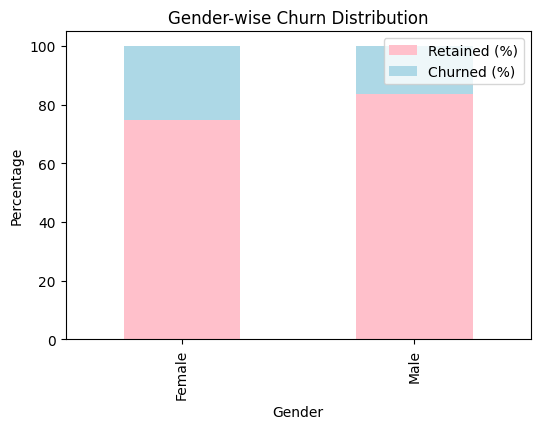

In [71]:
gender_dist.plot(kind="bar",stacked=True,figsize=(6,4),color=["pink","lightblue"])
plt.title("Gender-wise Churn Distribution")
plt.ylabel("Percentage")
plt.show()

The stacked bar chart visually reinforces these numbers.

The blue "Churned" segment is visibly larger for the "Female" bar than for the "Male" bar.

The purple "Retained" segment for males reaches higher up the y-axis, indicating a more stable customer base in that segment.


In [72]:
pivot_geo_age=pd.pivot_table(df,values="Exited",observed=True,index="Geography",columns="AgeGroup",aggfunc="mean")*100
pivot_geo_age

AgeGroup,<30,30-45,46-60,60+
Geography,,,,
France,4.868549,12.349800,45.794393,19.913420
Germany,12.527964,26.092991,67.330677,38.938053
Spain,8.474576,12.533693,40.656566,20.833333


The "Danger Zone" (46-60): Across all three countries, customers aged 46 to 60 have the highest churn rates. This is the most critical segment for retention efforts. In Germany, this reaches a staggering 67.3%, meaning more than 2 out of 3 customers in this bracket are leaving.

The Germany Outlier: Germany consistently shows higher churn rates across every age group compared to France and Spain. Even its youngest demographic (<30) churns at 12.5%, which is nearly triple the rate of the same demographic in France (4.9%).

The "Golden" Segment (<30 in France): The most loyal customers appear to be young adults in France, with a churn rate of only 4.9%.

Churn "Cool-Down" after 60: Interestingly, churn rates drop significantly once customers pass the age of 60. While still higher than the youngest groups, the 60+ demographic is much more stable than the 46-60 group.

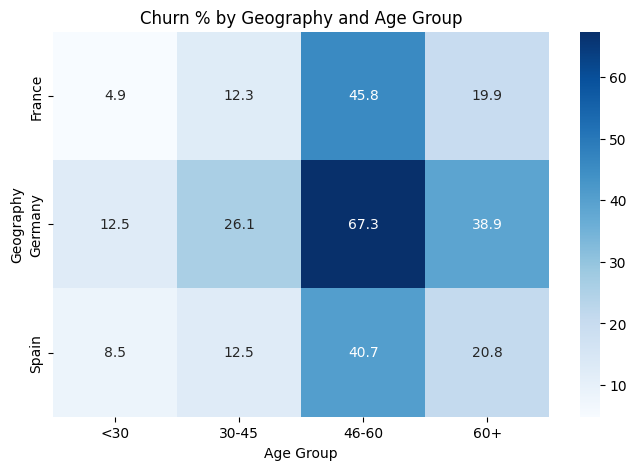

In [73]:
plt.figure(figsize=(8,5))
sns.heatmap(pivot_geo_age,annot=True,fmt=".1f",cmap="Blues")
plt.title("Churn % by Geography and Age Group")
plt.xlabel("Age Group")
plt.ylabel("Geography")
plt.show()

Prioritize Germany: The deep blue row for Germany suggests that macro-factors (local competition, service quality in the region, or pricing) are driving customers away regardless of age.

Targeted Retention: Retention efforts should be aggressively focused on the 46-60 age group. Since this group is likely more established financially, their exit represents a significant loss in potential high-value accounts.

In [74]:
df["Balance_Segment"]=df["Balance"].apply (lambda x: "Zero" if x==0 else ("Low" if x<=100000 else "High"))

In [75]:
balance_churn=df.groupby("Balance_Segment")["Exited"].mean()*100
balance_churn

,Exited
Balance_Segment,
High,25.234424
Low,20.580808
Zero,13.823611


The "Wealthy Churn " Paradox: Surprisingly, customers with High Balances are the most likely to leave the bank (25.2%). Usually, one might expect high-balance customers to be more "sticky" or invested, but here they represent the highest risk.

Zero-Balance Loyalty: Customers with a Zero Balance have the lowest churn rate at 13.8%. This is nearly half the churn rate of the high-balance segment.

Linear Correlation: There is a clear positive correlation here: as account balance increases, the likelihood of churning also increases.

In [76]:
salary_churn=df.groupby("Salary_Segment",observed=True)["Exited"].mean()*100
salary_churn

,Exited
Salary_Segment,
Low,20.00
Lower-Mid,19.80
Upper-Mid,20.12
High,21.56


Independence of Variables: unlike Balance, Salary has almost no impact on churn behavior. The churn rates across all four segments are remarkably stable, hovering between 19.8% and 21.6%.

The "Flat" Trend: There is no significant linear trend here. A customer earning a "Low" salary is essentially just as likely to leave as someone earning an "Upper-Mid" salary.

Minor Variance in "High" earners: There is a very slight uptick in the "High" salary segment (21.56%), but it is marginal (only ~1.7 percentage points higher than the Lower-Mid group). This suggests that while wealth (Balance) drives churn, income (Salary) is not a primary driver.

In [77]:
credit_churn=df.groupby("Credit_Risk",observed=True)["Exited"].mean()*100
credit_churn

,Exited
Credit_Risk,
Low,21.689498
Medium,19.722368
High,19.865212


The Stability of Credit Risk: There is very little variance across these groups. Whether a customer is categorized as "Low" or "High" risk, the churn rate stays within a tight 2 percentage point window.

The "Low Risk" Paradox: Interestingly, the "Low Risk" segment (traditionally the most desirable customers for a bank) actually shows a slightly higher churn rate (21.69%) than those in the High Risk category (19.87%).

Lack of Predictive Power: similar to salary, Credit Risk alone is a weak predictor of churn. Customers with better credit profiles might simply have more options and are therefore slightly more prone to "shopping around" for better banking terms elsewhere.

In [78]:
pivot_financial=pd.pivot_table(df,values="Exited",index="Balance_Segment",columns="Credit_Risk",aggfunc="mean",observed=True)*100
pivot_financial

Credit_Risk,Low,Medium,High
Balance_Segment,,,
High,26.912568,24.100327,24.983344
Low,22.795699,20.128824,19.076305
Zero,14.511873,13.646368,13.339302


The "Flight Risk" Apex: The highest churn rate in the entire table (26.91%) belongs to the High Balance/Low Credit Risk segment. These are arguably the bank's most valuable customers: they have significant assets and are financially responsible. Their exit represents a mojor loss of high-quality capital.

Balance is the "true" Driver: Within any credit category, as the balance moves form Zero-> Low-> High, the churn rate always increases. However, moving across credit risks for the same balance segment shows much smaller fluctuations. This confirms that stored wealth is a much stronger predictor of exit than credit score.

Credit Risk Sensitivity: Low-credit-risk customers are consistently more likely to churn than high-credit-risk customers across every balance tier.
    Hypothesis: Low-risk customers likely have better financial literacy and higher mobility, making them more sensitive to better interest rates or "new member" bonuses at competing banks.

The Zero-Balance Floor: Regardless of credit risk, sero-balance customers remainthe most loyal (or perhaps just the most inactive), with churn staying between 13-14%.

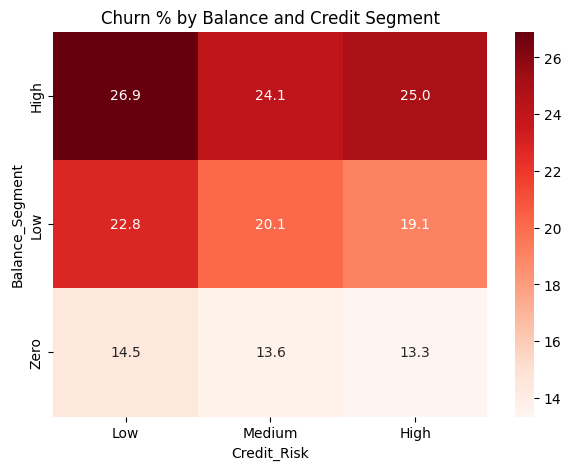

In [79]:
plt.figure(figsize=(7,5))
sns.heatmap(pivot_financial,annot=True,fmt=".1f",cmap="Reds")
plt.title("Churn % by Balance and Credit Segment")
plt.show()

The "Darkest' Hot Spot (High Balance/Low Credit Risk): At 26.9%, this is the most critical area of the map. These customers have the financial capacity (High Balance) and the marketability (Low Credit Risk) to switch banks easily. This segment is essentially a "loss-leader" for the bank right now.

The Horizontal Trend (balance is King): As we move vertically from the bottom row (Zero Balance) to the top row (High Balance), the colors darken significantly. This visually proves that Balance is the primary driver of churn risk in this dataset, regardles of Credit risk.

The Vertical Trend (Credit Sensitivity): Within each horizontal row, the leftmost cell (Low Credit Risk) is consistently darker than the others. This indicates that lower credit risk consistency correlates with higher churn, possibly because these customers have more access to competitive offers from other institutions.

The "Safe Zone" (Bottom Right"): Customers with Zero balances and High Credit Risk have the lowest churn at 13.3%. This group represents the most stable, albeit perhaps least active, segment.

In [80]:
high_balance_df=df[df["Balance"]>df["Balance"].median()]

In [81]:
high_balance_churners=high_balance_df[high_balance_df["Exited"]==1]

In [82]:
high_balance_churners.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,Balance_Segment,Credit_Risk,Product_Segment,Salary_Segment,Tenure_Segment
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,30-45,High,Low,Multiple Products,Upper-Mid,Long-term
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,30-45,High,Medium,Two Products,High,Long-term
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,<30,High,Low,Multiple Products,Upper-Mid,Mid-term
16,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1,46-60,High,Medium,Single Product,Low,New
35,475,France,Female,45,0,134264.04,1,1,0,27822.99,1,30-45,High,Low,Single Product,Low,NaN


In [83]:
total_high_balance=len(high_balance_df)
churn_high_balance=len(high_balance_churners)
churn_rate=(churn_high_balance/total_high_balance)*100
print("Total High Balance Customers:",total_high_balance)
print("Churned High Balance Customers:",churn_high_balance)
print(f"Churn Rate:{churn_rate:.2f}%")

Total High Balance Customers: 5000
Churned High Balance Customers: 1249
Churn Rate:24.98%


A churn rate of ~25% for high-balance customers is a major red flag for any financial institution. Since this group represents 5000 individuals with high capital, losing 1,249 of them means a substential outflow of Assets Under Management (AUM).

This 24.98% figure perfectly aligns with the 25.2% average we saw in the earlier "High Balance" segment analysis This confirms that the risk is systemic within this wealth tier and wasn't skewed by small sample size.

While the overall churn rate of the entire dataset might be lower, the impact of this 25% is disproportionately high. It is far more expensive to replace one high-balance customer than multiple zero-balance customers.

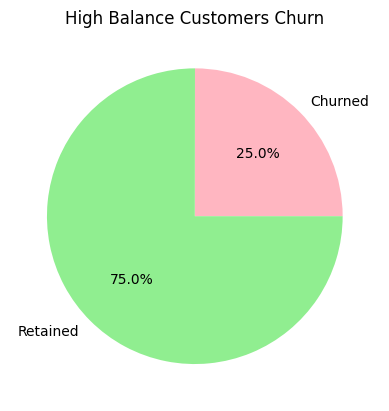

In [84]:
counts=[churn_high_balance,total_high_balance-churn_high_balance]
labels=["Churned","Retained"]
plt.pie(counts,labels=labels,autopct="%1.1f%%",colors=["lightpink","lightgreen"])
plt.title("High Balance Customers Churn")
plt.show()

The Quarter Rule: Exactly 25.0% of the high-balance customers have churned.

Asset Risk: While the majority (75%) remain, losing a quater of the high-balance segment is critical because it represents a large outflow of capital compared to low-balance churners.

In [85]:
pivot_salary_balance=pd.pivot_table(df,values="Exited",observed=True,index="Balance_Segment",columns="Salary_Segment",aggfunc="mean")*100
pivot_salary_balance

Salary_Segment,Low,Lower-Mid,Upper-Mid,High
Balance_Segment,,,,
High,26.258389,24.094356,24.584718,25.986842
Low,17.322835,21.000000,20.731707,23.155216
Zero,13.052859,13.691128,13.769752,14.814815


There is a clear positive correlation between account balance and churn rate. Regardless of salary, customers with higher balances are significantly more likely to leave.
High Balance: Churn rates are highest here, ranging from approximately 24.1% to 26.3%.
Zero Balance: Churn rates are at their lowest, ranging from 13.1% to 14.8%.
The Gap: A customer with a "High" balance is nearly twice as likely to exit as a customer with a "Zero" balance.

Unlike balance, salary segments do not show a dramatic or linear trend in churn.
In the High Balance segment, those with "Low" salaries actually have the highest churn (26.26%).
In the Zero Balance segment, the churn rate slightly increases as salary increases (from 13.05% at Low to 14.81% at High), but the delta is small.

The most critical segment for retention is the High Balance/ Low Salary group. At 26.25%, they represent the highest churn risk in this dataset. This might suggest that "savers" with lower income are more sensitive to fees, interest rates, or better offers elsewhere.

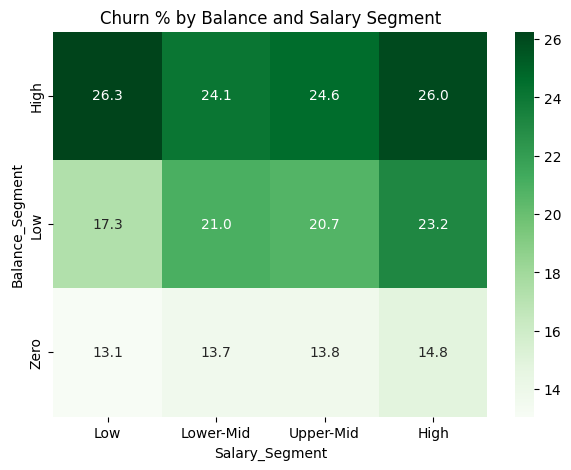

In [86]:
plt.figure(figsize=(7,5))
sns.heatmap(pivot_salary_balance,annot=True,fmt=".1f",cmap="Greens")
plt.title("Churn % by Balance and Salary Segment")
plt.show()

The most striking feature of this heatmap is the clear horizontal banding. The colors transition from dark green (high churn) at the top to very light green (low Churn) at the bottom.
Balance is the primary predictor: The vertical shift (moving from "Zero" to "High" balance) creates a massive jump in churn probability regardless of the column(salary).
The "Safety" Zone: The bottom row (Zero Balance) is consistently pale, indicating that customers with no balance are the most "stable" or least likely to officially exit.

Interestingly, the top row (High Balance) doesn't follow a straight linear trend across salaries:
The Extremes are Risky: Churn is highest at the Low Salary (26.3%) and High Salary (26.0%) ends.
The Middle is Stable: The Lower-Mid (24.1%) and Upper-Mid (@4.6%) segments actually show a slight dip in churn. This "U-shape " suggests that mid-income earners with high balances might be the bank's most loyal high-value segment.

The Low Balance/ Low salary segment (17.3%) is a notable outlier. It is significantly lighter than the rest of the "Low Balance" row. This group seems unusually loyal compared to their peers in higher salary brackets.

In [87]:
balance_risk=df.groupby("Balance_Segment").agg(Total_Balance=("Balance","sum"),Churned_Balance=("Balance",lambda x:x[df.loc[x.index,"Exited"]==1].sum()))

In [88]:
balance_risk["Risk (%)"]=(balance_risk["Churned_Balance"]/balance_risk["Total_Balance"])*100
balance_risk

,Total_Balance,Churned_Balance,Risk (%)
Balance_Segment,,,
High,6.353449e+08,1.594897e+08,25.102854
Low,1.295140e+08,2.609840e+07,20.151024
Zero,0.000000e+00,0.000000e+00,NaN


The balance-based churn risk analysis reveals clear differences across customer segments. Customers in the high balance segment contribute the largest share of total balances and also exhibit the highest financial churn risk at approximately 25.1%, indicating that a significant portion of high-value funds is being lost due to churn. In comparison, the low balance segment shows a lower risk of around 20.15%, suggesting relatively lower financial impact despite customer exits. The zero balance segment results in an undefined (NaN) churn risk due to the absence of any monetary value, making it irrelevant from a financial risk perspective. Overall, the analysis highlights that high balance customers pose the greatest fiancial risk to the bank, emphasizing the need for targeted retention strategies focused on high-value clients rather than just overall churn reduction.

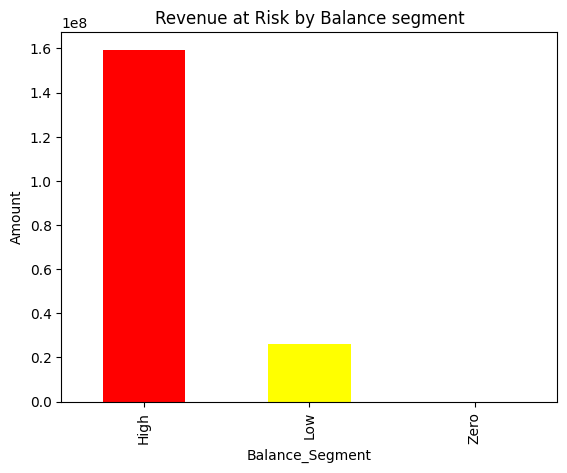

In [89]:
balance_risk["Churned_Balance"].plot(kind="bar",color=("red","yellow"))
plt.title("Revenue at Risk by Balance segment")
plt.ylabel("Amount")
plt.show()

The visualization of revenue at risk across balance segments shows a highly skewed distribution, where the high balance segment contributes the overwhelming majority of churn-related financial loss. Despite representing a smaller portion of customers,high balance clients account for the largest revenue at risk, indicating that churn in this segment has a disproportionately large financial impact on the bank. In contrast, the low balance segment contributes significantly less to revenue loss, suggesting that while churn may occur, its financial consequences are relatively limited. The zero balance segment shows negligible or no revenue at risk,a s expected, since these accounts do not hold moneytary value. Overall, the analysis highlights that the bank's primary vulnerabilty lies in losing high-value customers, emphesizing the importance of prioritizing retention strategies for high balance segments to minimize financial losses.

In [90]:
high_value=df[(df["Balance"]>df["Balance"].median()) | (df["EstimatedSalary"]>df["EstimatedSalary"].median())]

In [91]:
high_value_churn=high_value["Exited"].mean()*100

In [92]:
print(f"High Value Customer Churn Rate:{high_value_churn:.2f}%")

High Value Customer Churn Rate:22.18%


High-value customers represent the core capital of the bank. A 22% churn rate in this segment is significantly more "expensive" than churn in the zero-balance or low-balance segments.

In [93]:
active_churn=df.groupby("IsActiveMember")["Exited"].mean()*100
active_churn

,Exited
IsActiveMember,
0,26.850897
1,14.269074


There is a significant difference (about 12.5 percentage points) between active and inactive members. This confirms that engagement is strong predictor of whether a customer will stay.

Inactive members are nearly twice as likely to exit compared to active members.

Since even active members have a ~14% churn rate, actively alone isn't a "silver bullet", but it is a primary lever for retention strategies.

In [94]:
product_churn=df.groupby("NumOfProducts")["Exited"].mean()*100
product_churn

,Exited
NumOfProducts,
1,27.714398
2,7.581699
3,82.706767
4,100.000000


Usually, we expect more products to mean higher loyalty. However, here, moving from 2 to 3 products is a "red flag".

A 100% churn rate for 4 products is statistically extreme. It's possible there are very few people in the 3 and 4 categories, making the percentages look more alarming than they are.

The significant drop in churn for customers with 2 products suggests that "multi-product" users are the most loyal segment- until they hit a threshold where the experience likely degrades.

In [95]:
card_churn=df.groupby("HasCrCard")["Exited"].mean()*100
card_churn

,Exited
HasCrCard,
0,20.814941
1,20.184266


There is only a 0.63% difference between those who have a credit card and those who don't. This suggests that credit card ownership, on its own , is not a strong predictor of churn.

Because the members are so close, this variable might not carry much weight in a predictive model (like a Logistic Regression or Random Forest). It behaves more like "noise" compared to the high-impact variables like IsActiveMember or NumOfProducts.

Credit cards are often secondary products. While they represent a financial link, they don't seem to drive the same "stickiness" that having two general bank products does.

In [96]:
pivot_table_multi=pd.pivot_table(df,values="Exited",index="Tenure",columns=["NumOfProducts","IsActiveMember","HasCrCard"],aggfunc="mean")
pivot_table_multi.round(1)
pivot_table_multi=pivot_table_multi.dropna(axis=1,how="all")
pivot_table_multi=pivot_table_multi.fillna(0)
pivot_table_multi

NumOfProducts          1                                       2            \
IsActiveMember         0                   1                   0             
HasCrCard              0         1         0         1         0         1   
Tenure                                                                       
0               0.263158  0.389610  0.244444  0.210526  0.045455  0.153846   
1               0.381579  0.431694  0.204082  0.189573  0.123077  0.090909   
2               0.433333  0.381818  0.197368  0.209302  0.082192  0.093023   
3               0.215190  0.336788  0.207792  0.211111  0.093023  0.120567   
4               0.357143  0.395480  0.278481  0.157303  0.118644  0.114458   
5               0.402985  0.396552  0.227273  0.162791  0.065789  0.078788   
6               0.320513  0.398876  0.171875  0.182353  0.107692  0.080882   
7               0.242424  0.314917  0.221053  0.148571  0.100000  0.100000   
8               0.385542  0.295699  0.278689  0.148718  0.153846  0.078431   
9               0.470588  0.412060  0.188406  0.176829  0.094595  0.094937   
10              0.272727  0.388889  0.111111  0.170732  0.161290  0.090909   

NumOfProducts                              3                                \
IsActiveMember         1                   0                   1             
HasCrCard              0         1         0         1         0         1   
Tenure                                                                       
0               0.162162  0.116667  1.000000  1.000000  1.000000  0.000000   
1               0.071429  0.062112  1.000000  0.727273  0.333333  0.833333   
2               0.043478  0.033981  1.000000  1.000000  0.000000  0.625000   
3               0.075758  0.038889  0.833333  0.894737  1.000000  0.727273   
4               0.073529  0.065089  1.000000  0.666667  0.000000  0.600000   
5               0.000000  0.055901  0.714286  0.928571  1.000000  0.800000   
6               0.086207  0.076142  1.000000  1.000000  1.000000  0.750000   
7               0.055556  0.033333  1.000000  0.916667  0.666667  0.500000   
8               0.111111  0.037433  0.800000  0.833333  0.750000  1.000000   
9               0.026667  0.041667  1.000000  1.000000  0.333333  0.600000   
10              0.066667  0.055556  1.000000  0.857143  1.000000  1.000000   

NumOfProducts     4                 
IsActiveMember    0         1       
HasCrCard         0    1    0    1  
Tenure                              
0               0.0  0.0  0.0  0.0  
1               1.0  1.0  0.0  0.0  
2               1.0  1.0  1.0  1.0  
3               0.0  1.0  1.0  1.0  
4               1.0  1.0  0.0  0.0  
5               1.0  1.0  1.0  1.0  
6               0.0  1.0  1.0  0.0  
7               1.0  0.0  1.0  1.0  
8               1.0  1.0  1.0  1.0  
9               1.0  1.0  1.0  1.0  
10              0.0  1.0  0.0  1.0

The data confirms that having 2 products is remarkably stable.
IsActiveMember=1 with 2 products: Churn rates across almost all tebnure years are consistently low, often dipping into the 3% to 7% range (e.g., Tenure 2,7 and 10).
    This is the "Gold Standard" customer profile. Whatever we are doing to keep 2-products active members is working.

The right side of the table is alarming.
4 Products: In almost every tenure year, the churn rate is 1.0 (100%).
3 Products: Churn is frequently 1.0 or very close to it (e.g., 0.80 to 0.92), regardless of whether they have a credit card or are active.
    This suggests a systemic issue. Perhaps the bank's systems or fees become prohibitive when a customer hits 3+ products, or these customers are "gaming" a system before leaving. It is a product-driven failure, not a tenure-driven one.

If we look at NumOfProducts=1, we notice the churn rates for the first few years:
    For inactive members with 1 product and no credit card, churn starts at 26% and climbs to 43% by Year 2.
    The first 24 months are critical for 1-product customers. If we don't cross-sell them a second product or get them "Active" by Year 2, there is nearly 50/50 chance they will leave.

Earlier we thought HasCrCard was irrelevent. In this pivot table, a slight pattern emerges for 1-product Inactive Members:
    Compare HasCrCard 0 vs 1 under NumOfProducts 1: Those with a card often have higher churn in the early years (e.g., Tenure 1: 38% vs 43%).
    For customers who aren't very engaged, the credit card fee might actually be the "trigger" that makes them close their account.

In [97]:
pivot_plot = pivot_table_multi.copy()

pivot_plot.columns.names = ['NumOfProducts', 'IsActiveMember', 'HasCrCard']
p_values = pivot_plot.columns.get_level_values('NumOfProducts')
a_values = pivot_plot.columns.get_level_values('IsActiveMember')
c_values = pivot_plot.columns.get_level_values('HasCrCard')
pivot_plot.columns = [f"NumOfProducts={p} | IsActiveMember={a} | HasCrCard={c}" for p, a, c in zip(p_values, a_values, c_values)]

In [98]:
top_cols=pivot_plot.mean().sort_values(ascending=False).head(5).index
pivot_top=pivot_plot[top_cols].reset_index()
pivot_top.columns=["Tenure"]+list(top_cols)

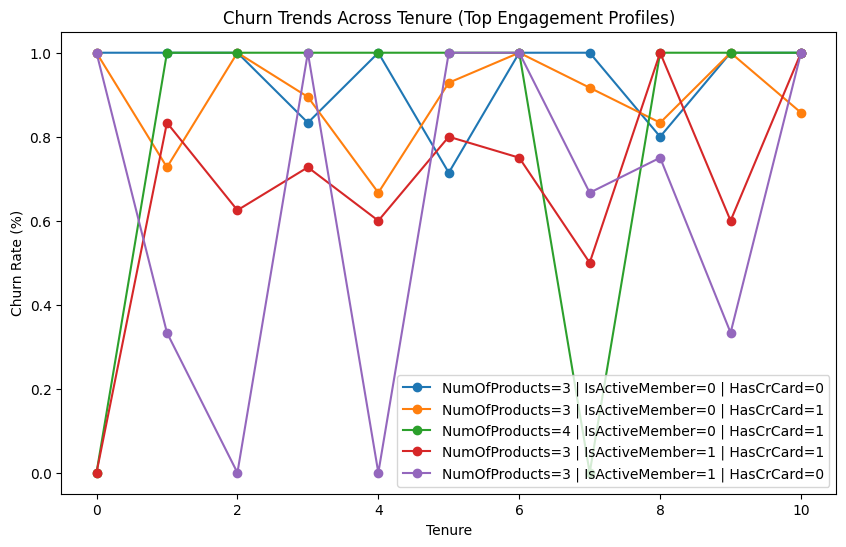

In [104]:
plt.figure(figsize=(10,6))

for col in top_cols:
    plt.plot(pivot_top["Tenure"],pivot_top[col],marker="o",label=col)

plt.title("Churn Trends Across Tenure (Top Engagement Profiles)")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")
plt.legend()
plt.show()

The "All-or-Nothing' Volatility:
The sharp zig-zags between 0.0 and 1.0 (0% and 100%) churn are classic sign of small sample sizes in these specific sub-segments.
  When we drill down this deep (e.g., NumOfProducts=4|Active=0|Card=1), we likely only have 1 or 2 customers per tenure year. If that one person leaves, the rate hits 100%; if they stays, it hits 0%.
  We should verify the "N" (count) for these groups. While the trend looks chaotic, the average above 0.6) confirms that high products ownership is a massive churn risk.

Product 4 (Green Line)-The "Cliff":
Let's have a look at the green line representing customers with 4 products. It stays at the 1.0 ceiling for almost every tenure year except for a strange dip at Tenure 7.
  Tenure does not "save" these customers (Tenure 8-10) with 4 products
  are exiting at nearly 100%. This reinforces that the problem is the product bundle itself, not the length of the relationship.

Active vs Inactive (3 Products):
Comparing the Dark Blue/Maroon lines (Inactive) against the Light Blue/Orange lines (Active) for 3 products:
  The Active profiles (lighter colors) show slightly more "dips" toward lower churn, especially in the mid-tenure range.
  Even for high-risk product counts, being an Active Member provides a small "buffer", though it is clearly not enough to offset the negative impact of having 3+ products.